<a href="https://colab.research.google.com/github/runessaa/-Streltsov-Projects/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%968_%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%BE%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Применение методов машинного обучения для решения задач классификации текстов. Метод Наивного Байеса. Метод опорных векторов**

## Задание 0. Найдите в глобальной сети или соберите свой датасет для классификации текстов (Пример: новости -> рубрики, комментарии в соц. сетях -> характер, )

* Количество классов в датасете должно превышать 2
* Язык текста в датасете: русский

- ### Пример датасетов: [Russian Texts](https://www.kaggle.com/datasets?search=text+classification+russian)

### Загрузите датасет

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('train.csv')

print("Форма датасета:", train_df.shape)
print("Колонки:", train_df.columns.tolist())
print("Распределение классов:")
print(train_df['category'].value_counts())

Форма датасета: (38740, 3)
Колонки: ['oid', 'category', 'text']
Распределение классов:
category
autosport       3160
extreme         3110
martial_arts    3050
motosport       3030
boardgames      3020
tennis          3000
esport          2990
athletics       2970
hockey          2950
volleyball      2950
football        2860
basketball      2850
winter_sport    2800
Name: count, dtype: int64


### Разделите данные на обучающую и валидационную выборки

In [3]:
X = train_df['text']
y = train_df['category']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nРазмер обучающей выборки:", len(X_train))
print("Размер валидационной выборки:", len(X_val))


Размер обучающей выборки: 30992
Размер валидационной выборки: 7748


### При выполении дальнейших заданий поэксперементируйте с методами векторизации текста:


1. [Bag of Words](https://habr.com/ru/companies/mlclass/articles/270591/) (BOW): Bag of Words представляет текст как вектор, где каждый элемент обозначает количество вхождений конкретного слова в тексте. Процесс включает в себя создание словаря всех уникальных слов в корпусе текстов и подсчет частоты встречаемости каждого слова в отдельных текстах.

2. [TF-IDF](https://habr.com/ru/companies/otus/articles/755772/) (Term Frequency-Inverse Document Frequency): TF-IDF учитывает не только количество вхождений слова в текст, но и частоту его встречаемости в других текстах. Он вычисляет вес слова, умножая его частоту встречаемости (term frequency) на обратную частоту документа (inverse document frequency). Это позволяет снизить вес наиболее часто встречающихся слов, которые могут быть менее информативными.

3. Word Embeddings (например, [Word2Vec](https://habr.com/ru/articles/446530/) и [GloVe](https://jonathan-hui.medium.com/nlp-word-embedding-glove-5e7f523999f6)): Word Embeddings используют нейронные сети для создания векторных представлений слов, которые учитывают семантическую близость между словами. Нейронные сети обучаются на больших текстовых корпусах и захватывают семантические отношения между словами, что позволяет представить слова в векторном пространстве.

4. One-Hot Encoding: One-Hot Encoding преобразует каждое слово в уникальный вектор, где все элементы равны нулю, за исключением одного, который равен единице. Каждый вектор соответствует отдельному слову и используется для представления его в пространстве признаков.

5. [Count Vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html): Count Vectorizer подсчитывает количество раз, которое каждое слово встречается в тексте. Он создает вектор, в котором каждый элемент соответствует количеству вхождений конкретного слова в текст.

6. [Hashing Vectorizer](https://kavita-ganesan.com/hashingvectorizer-vs-countvectorizer/): Hashing Vectorizer преобразует каждое слово в уникальный числовой идентификатор с помощью хеширования. Он использует хеш-функцию для преобразования слова в числовое значение, которое затем используется в векторном представлении.

7. [Doc2Vec](https://habr.com/ru/articles/599513/): Doc2Vec является расширением метода Word2Vec и позволяет получить векторное представление не только отдельных слов, но и целых документов или текстов. Алгоритм обучает нейронную сеть, которая учитывает контекст и порядок слов в предложении, чтобы получить векторное представление документа. Это позволяет сравнивать и измерять семантическую близость между целыми текстовыми документами.

#### Оцените влияние разных методов на конечный результат

## Задание 1. Обучите модель классификатора Naive Bayes для решения поставленной задачи, используя пайплайн и подбор оптимальных параметров

In [4]:
pipeline_nb = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

parameters_nb = {
    'vect__max_df': (0.5, 0.75, 1.0),
    'vect__ngram_range': [(1,1), (1,2)],
    'clf__alpha': (0.01, 0.1, 1.0)
}

grid_search_nb = GridSearchCV(pipeline_nb, parameters_nb, cv=3, n_jobs=-1, scoring='accuracy')
grid_search_nb.fit(X_train, y_train)

print("Лучшие параметры Naive Bayes:", grid_search_nb.best_params_)
best_nb = grid_search_nb.best_estimator_

Лучшие параметры Naive Bayes: {'clf__alpha': 0.1, 'vect__max_df': 0.5, 'vect__ngram_range': (1, 1)}


### Вывод матрицы ошибок:

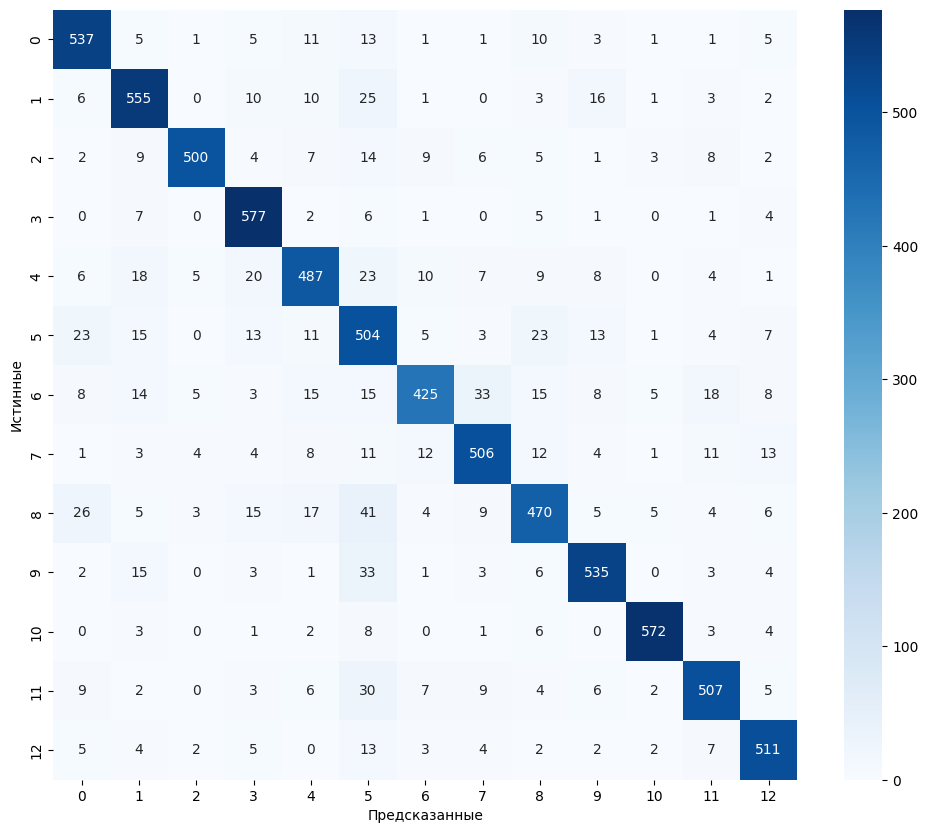

In [5]:
y_pred_nb = best_nb.predict(X_val)
cm = confusion_matrix(y_val, y_pred_nb)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.show()

### Оценка точности:

In [6]:
print("Точность Naive Bayes:", accuracy_score(y_val, y_pred_nb))
print(classification_report(y_val, y_pred_nb))

Точность Naive Bayes: 0.8629323696437791
              precision    recall  f1-score   support

   athletics       0.86      0.90      0.88       594
   autosport       0.85      0.88      0.86       632
  basketball       0.96      0.88      0.92       570
  boardgames       0.87      0.96      0.91       604
      esport       0.84      0.81      0.83       598
     extreme       0.68      0.81      0.74       622
    football       0.89      0.74      0.81       572
      hockey       0.87      0.86      0.86       590
martial_arts       0.82      0.77      0.80       610
   motosport       0.89      0.88      0.89       606
      tennis       0.96      0.95      0.96       600
  volleyball       0.88      0.86      0.87       590
winter_sport       0.89      0.91      0.90       560

    accuracy                           0.86      7748
   macro avg       0.87      0.86      0.86      7748
weighted avg       0.87      0.86      0.86      7748



## Задание 2. Обучите модель SVM (метод опорных векторов) для решения поставленной задачи, используя пайплайны и подбор оптимальных параметров

In [7]:
pipeline_svm = Pipeline([
    ('vect', TfidfVectorizer(max_features=10000)),
    ('clf', SVC())
])

parameters_svm = {
    'vect__ngram_range': [(1,1), (1,2)],
    'clf__C': [1, 10],
    'clf__kernel': ['linear']
}

grid_search_svm = GridSearchCV(pipeline_svm, parameters_svm, cv=3, n_jobs=-1, scoring='accuracy')
grid_search_svm.fit(X_train, y_train)

print("Лучшие параметры SVM:", grid_search_svm.best_params_)
best_svm = grid_search_svm.best_estimator_

Лучшие параметры SVM: {'clf__C': 1, 'clf__kernel': 'linear', 'vect__ngram_range': (1, 1)}


### Вывод матрицы ошибок:

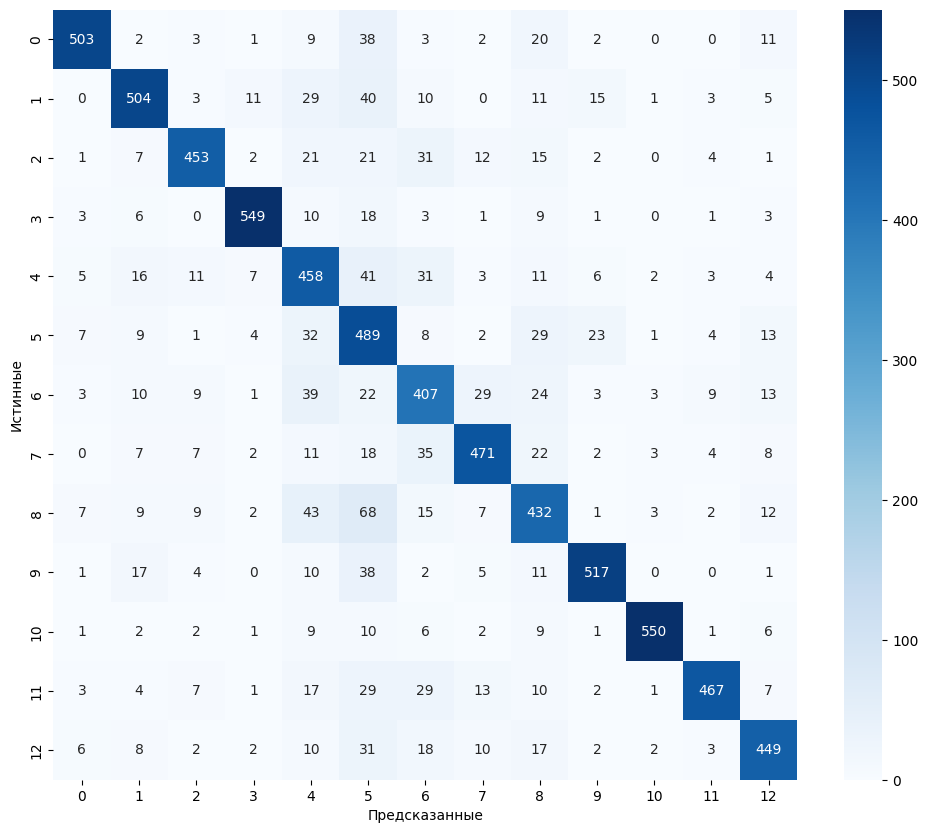

In [8]:
y_pred_svm = best_svm.predict(X_val)
cm = confusion_matrix(y_val, y_pred_svm)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.show()

### Оценка точности:

In [9]:
print("Точность SVM:", accuracy_score(y_val, y_pred_svm))
print(classification_report(y_val, y_pred_svm))

Точность SVM: 0.8065307176045431
              precision    recall  f1-score   support

   athletics       0.93      0.85      0.89       594
   autosport       0.84      0.80      0.82       632
  basketball       0.89      0.79      0.84       570
  boardgames       0.94      0.91      0.93       604
      esport       0.66      0.77      0.71       598
     extreme       0.57      0.79      0.66       622
    football       0.68      0.71      0.70       572
      hockey       0.85      0.80      0.82       590
martial_arts       0.70      0.71      0.70       610
   motosport       0.90      0.85      0.87       606
      tennis       0.97      0.92      0.94       600
  volleyball       0.93      0.79      0.86       590
winter_sport       0.84      0.80      0.82       560

    accuracy                           0.81      7748
   macro avg       0.82      0.81      0.81      7748
weighted avg       0.82      0.81      0.81      7748



## Задание 3. Обучите модель классификатора Decision Tree Classifier для решения поставленной задачи

In [10]:
pipeline_dt = Pipeline([
    ('vect', TfidfVectorizer(max_features=8000)),
    ('clf', DecisionTreeClassifier(random_state=42, max_depth=20))
])

pipeline_dt.fit(X_train, y_train)

Pipeline(steps=[('vect', TfidfVectorizer(max_features=8000)),
                ('clf', DecisionTreeClassifier(max_depth=20, random_state=42))])

### Вывод матрицы ошибок:

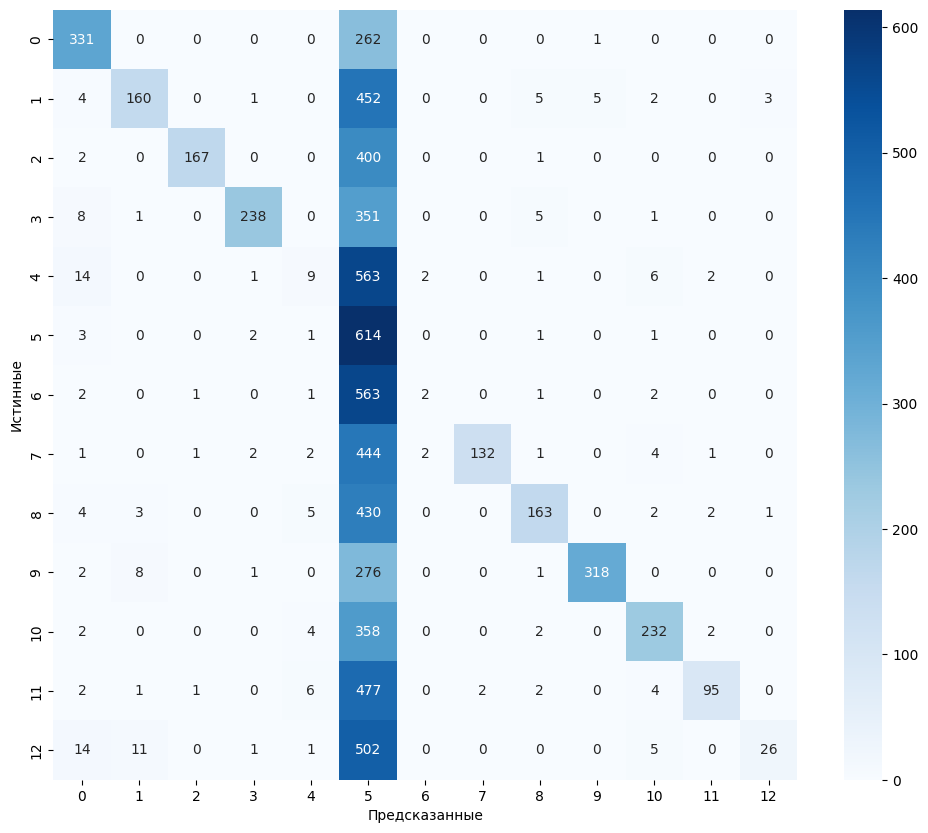

In [11]:
y_pred_dt = pipeline_dt.predict(X_val)
cm = confusion_matrix(y_val, y_pred_dt)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.show()

### Оценка точности:

In [12]:
print("Точность Decision Tree:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

Точность Decision Tree: 0.3209860609189468
              precision    recall  f1-score   support

   athletics       0.85      0.56      0.67       594
   autosport       0.87      0.25      0.39       632
  basketball       0.98      0.29      0.45       570
  boardgames       0.97      0.39      0.56       604
      esport       0.31      0.02      0.03       598
     extreme       0.11      0.99      0.19       622
    football       0.33      0.00      0.01       572
      hockey       0.99      0.22      0.36       590
martial_arts       0.89      0.27      0.41       610
   motosport       0.98      0.52      0.68       606
      tennis       0.90      0.39      0.54       600
  volleyball       0.93      0.16      0.27       590
winter_sport       0.87      0.05      0.09       560

    accuracy                           0.32      7748
   macro avg       0.77      0.32      0.36      7748
weighted avg       0.77      0.32      0.36      7748



## Задание 4. Обучите модель классификатора Random Forest Classifier для решения поставленной задачи

In [13]:
pipeline_rf = Pipeline([
    ('vect', TfidfVectorizer(max_features=8000)),
    ('clf', RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1))
])

pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('vect', TfidfVectorizer(max_features=8000)),
                ('clf',
                 RandomForestClassifier(n_estimators=150, n_jobs=-1,
                                        random_state=42))])

### Вывод матрицы ошибок:

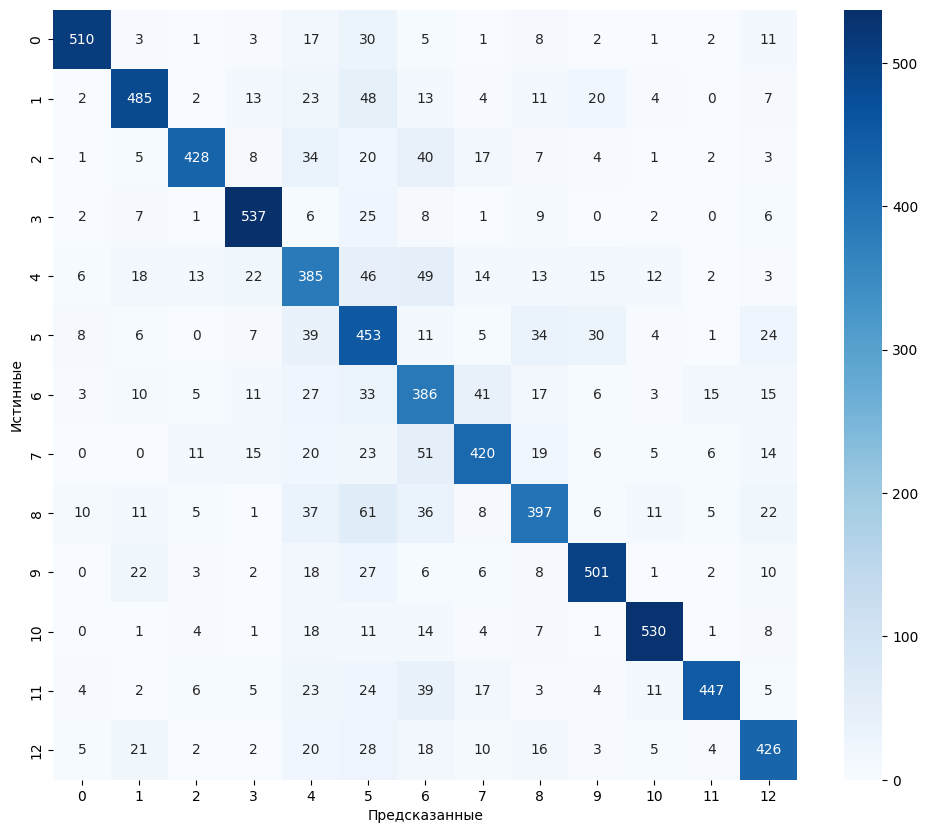

In [14]:
y_pred_rf = pipeline_rf.predict(X_val)
cm = confusion_matrix(y_val, y_pred_rf)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.show()

### Оценка точности:

In [15]:
print("Точность Random Forest:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

Точность Random Forest: 0.7621321631388746
              precision    recall  f1-score   support

   athletics       0.93      0.86      0.89       594
   autosport       0.82      0.77      0.79       632
  basketball       0.89      0.75      0.81       570
  boardgames       0.86      0.89      0.87       604
      esport       0.58      0.64      0.61       598
     extreme       0.55      0.73      0.62       622
    football       0.57      0.67      0.62       572
      hockey       0.77      0.71      0.74       590
martial_arts       0.72      0.65      0.69       610
   motosport       0.84      0.83      0.83       606
      tennis       0.90      0.88      0.89       600
  volleyball       0.92      0.76      0.83       590
winter_sport       0.77      0.76      0.76       560

    accuracy                           0.76      7748
   macro avg       0.78      0.76      0.77      7748
weighted avg       0.78      0.76      0.77      7748



## Подведите общие итоги и сделайте выводы

In [17]:
print(f"Naive Bayes: {accuracy_score(y_val, y_pred_nb):.4f}")
print(f"SVM: {accuracy_score(y_val, y_pred_svm):.4f}")
print(f"Decision Tree: {accuracy_score(y_val, y_pred_dt):.4f}")
print(f"Random Forest: {accuracy_score(y_val, y_pred_rf):.4f}")

Naive Bayes: 0.8629
SVM: 0.8065
Decision Tree: 0.3210
Random Forest: 0.7621


На данном датасете лучше всего сработал Naive Bayes. Он заметно обогнал остальные модели. SVM тоже показал неплохой результат, а Random Forest выступил средне. Decision Tree сильно отстал от всех. Также правильный подбор параметров и ограничение количества признаков в TfidfVectorizer довольно сильно влияют на итоговое качество. В целом, для классификации русских текстов Naive Bayes оказался самым эффективным алгоритмом в этой работе.